# Example: Rebalancing Engine and Scorecard

In this example, we wire the **Cobb-Douglas utility allocator** into a full rebalancing engine with trigger rules (drawdown limits, turnover caps), produce a four-row scorecard comparing the engine against the Session 1 min-var portfolio, an equal-weight buy-and-hold, and a risk-free baseline, and run a sensitivity analysis over the key parameters $\lambda$ (risk-aversion gain) and $\epsilon$ (minimum share floor).

> **By the end of this example, you will be able to:**
> * __Run the Cobb-Douglas rebalancing engine:__ Execute the rebalancing engine with production-style trigger rules including drawdown limits and turnover caps. Observe how tighter or looser drawdown thresholds affect capital protection and recovery.
> * __Produce a strategy scorecard:__ Build a four-row scorecard comparing the AI engine to the Session 1 min-var portfolio, an equal-weight buy-and-hold, and a risk-free benchmark. Evaluate return, volatility, Sharpe ratio, and maximum drawdown across strategies.
> * __Analyze sensitivity to key parameters:__ Sweep the lambda gain and epsilon parameters to map their effect on portfolio performance. Identify the parameter sweet spot that balances responsiveness with diversification.

Let's dive in!

___

## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

Load the data produced by the `BuildCobbDouglasAllocator` notebook (Example 1 in this session). The `let...end` block below reads `engine-run-data.jld2` and populates the following globals: `my_tickers::Vector{String}`, `price_matrix::Matrix{Float64}`, `market_prices::Vector{Float64}`, `lambda_series::Vector{Float64}`, `gm_ema::Vector{Float64}`, `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`, `context::MyRebalancingContextModel`, and the three baseline wealth series `minvar_wealth::Vector{Float64}`, `equalweight_wealth::Vector{Float64}`, and `riskfree_wealth::Vector{Float64}`. It also defines the scalar constants `Δt`, `N_short`, `N_long`, `offset`, `n_trading_days`, `B₀`, `r_f`, and `K`.

In [2]:
let
    # --- Step 1: Load saved data from Example 1 ---
    data = load_results(joinpath(_PATH_TO_DATA, "engine-run-data.jld2"));

    # --- Step 2: Extract market and engine data into global scope ---
    global my_tickers         = data["my_tickers"]::Vector{String};
    global price_matrix       = data["price_matrix"]::Matrix{Float64};
    global lambda_series      = data["lambda_series"]::Vector{Float64};
    global market_prices      = data["market_prices"]::Vector{Float64};
    global gm_ema             = data["gm_ema"]::Vector{Float64};
    global sim_params         = data["sim_params"]::Dict{String,Tuple{Float64,Float64,Float64}};
    global context            = data["context"]::MyRebalancingContextModel;
    global minvar_wealth      = Float64.(data["minvar_wealth"]);
    global equalweight_wealth = Float64.(data["equalweight_wealth"]);
    global riskfree_wealth    = Float64.(data["riskfree_wealth"]);
    global r_f                = Float64(data["r_f"]);

    # --- Step 3: Trading calendar constants (match Example 1) ---
    global Δt             = 1.0 / 252.0;          # daily time step (fraction of a trading year)
    global N_short        = 21;                   # short EMA window (approx 1 month)
    global N_long         = 63;                   # long EMA window (approx 3 months)
    global offset         = N_short + N_long;     # 84-day warmup before trading starts
    global n_trading_days = 252;                  # number of active trading days
    global B₀             = context.B;            # initial budget from the context
    global K              = length(my_tickers);    # number of assets in the portfolio

    println("Loaded engine data: $(K) tickers, $(n_trading_days) trading days after $(offset) warmup")
    println("  Tickers: $(my_tickers)")
    println("  r_f (continuous, %/yr): $(round(r_f*100, digits=2))")
end

Loaded engine data: 10 tickers, 252 trading days after 84 warmup


  Tickers: ["AAPL", "MSFT", "NVDA", "JNJ", "JPM", "PG", "XOM", "BA", "GS", "AMD"]
  r_f (continuous, %/yr): 4.5


### Implementation
The `scorecard_metrics` function computes performance metrics from a wealth time series. It takes a `wealth::Array{Float64,1}` vector (daily wealth values) and a `label::String` (strategy name), and returns a tuple of `(label, total_return, volatility, sharpe_ratio, max_drawdown)` with return, volatility, and drawdown expressed as percentages.

In [3]:
"""
    scorecard_metrics(wealth::Array{Float64,1}, label::String) -> Tuple

Compute performance metrics from a daily wealth time series.

### Arguments
- `wealth::Array{Float64,1}`: daily wealth values (e.g., portfolio value over time).
- `label::String`: strategy name used to tag the output row.

### Returns
A tuple `(label, total_return, volatility, sharpe_ratio, max_drawdown)` where return, volatility,
and max drawdown are expressed as percentages.
"""
function scorecard_metrics(wealth::Array{Float64,1}, label::String)

    # --- Step 1: Compute daily simple returns ---
    returns = diff(wealth) ./ wealth[1:end-1];

    # --- Step 2: Compute cumulative return (%) ---
    total_return = (wealth[end] / wealth[1] - 1.0) * 100;

    # --- Step 3: Compute annualized volatility (%) ---
    vol = std(returns) * sqrt(252) * 100;

    # --- Step 4: Compute Sharpe ratio (return / vol) ---
    # Guard against deterministic series (e.g. continuously-compounded risk-free).
    # std of a constant stream is numerically ~1e-15 rather than exactly zero, so
    # `vol > 0` is not strict enough — we need a tolerance well above FP noise but
    # well below any real asset's annualized vol.
    sharpe = vol > 1e-6 ? total_return / vol : 0.0;

    # --- Step 5: Compute maximum drawdown (%) ---
    peak = accumulate(max, wealth);
    dd = maximum((peak .- wealth) ./ peak) * 100;

    # --- Step 6: Return rounded metrics ---
    return (label, round(total_return, digits=2), round(vol, digits=2),
        round(sharpe, digits=2), round(dd, digits=2))
end;

___
## Task 1: Cobb-Douglas Rebalancing Engine with Trigger Rules
We run the Cobb-Douglas utility allocator inside the full rebalancing engine with realistic trigger rules: a 15% drawdown limit (circuit breaker) and a 50% turnover cap (trading cost control). We compare three drawdown thresholds to see how the safety net affects performance.

> __What should you see?__
>
> Tighter drawdown limits (10%) cause the engine to de-risk to cash earlier and more often, protecting capital but potentially missing recoveries. Looser limits (25%) allow more volatility. The engine uses Cobb-Douglas utility to decide _how_ to allocate; the trigger rules decide _whether_ to allocate.

The code below sweeps three drawdown limits using [the `run_rebalancing_engine(...)` function](../../code/docs/build/session2.html), and the results are stored in the `dd_wealth_curves::Dict{Float64, Array{Float64,1}}` variable.

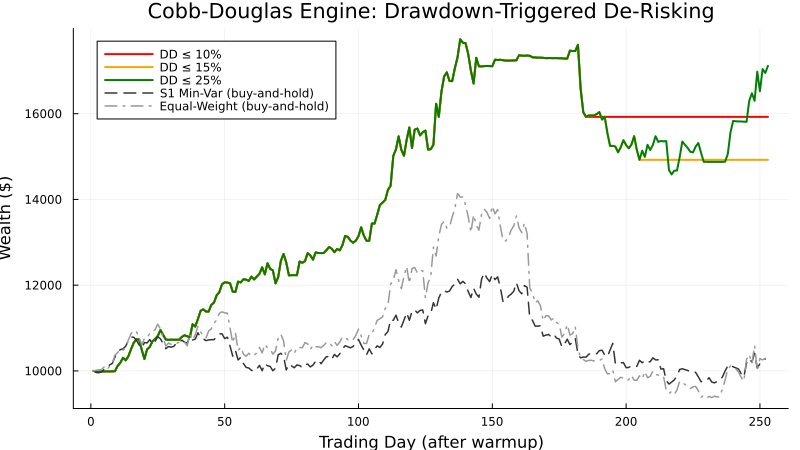

In [4]:
let
    # --- Step 1: Define drawdown thresholds and plot styling ---
    drawdown_limits = [0.10, 0.15, 0.25];                  # three drawdown trigger levels to compare
    colors          = [:red :orange :green];                # color per threshold
    labels          = ["DD ≤ 10%", "DD ≤ 15%", "DD ≤ 25%"]; # legend labels

    # Storage: maps each drawdown limit to its wealth curve
    global dd_wealth_curves = Dict{Float64, Array{Float64,1}}();

    # --- Step 2: Initialize the plot ---
    p = plot(size=(800, 450), title="Cobb-Douglas Engine: Drawdown-Triggered De-Risking",
        xlabel="Trading Day (after warmup)", ylabel="Wealth (\$)", legend=:topleft)

    # --- Step 3: Sweep drawdown limits ---
    for (j, dd_limit) ∈ enumerate(drawdown_limits)

        # Build trigger rules: drawdown limit varies, turnover cap fixed at 50%
        rules = build(MyTriggerRules, (
            max_drawdown = dd_limit,
            max_turnover = 0.50,
            rebalance_schedule = ones(Int, n_trading_days)  # rebalance every day
        ));

        # Run the rebalancing engine with Cobb-Douglas allocator
        results = run_rebalancing_engine(context, rules, lambda_series;
            offset=offset, allocator=:cobb_douglas);

        # Convert allocation results into a wealth time series
        wealth = compute_wealth_series(results, price_matrix, my_tickers; offset=offset);
        dd_wealth_curves[dd_limit] = wealth;  # store for later use

        # Plot this drawdown scenario
        plot!(p, 1:length(wealth), wealth, label=labels[j], linewidth=2, color=colors[j])
    end

    # --- Step 4: Overlay the Session 1 min-var and equal-weight baselines ---
    plot!(p, 1:length(minvar_wealth), minvar_wealth,
        label="S1 Min-Var (buy-and-hold)", linewidth=1.5, color=:gray20, linestyle=:dash)
    plot!(p, 1:length(equalweight_wealth), equalweight_wealth,
        label="Equal-Weight (buy-and-hold)", linewidth=1.5, color=:gray60, linestyle=:dashdot)
    p
end

___
## Task 2: Scorecard, Engine vs. Baselines
We produce a scorecard comparing three strategies: the AI Cobb-Douglas engine (DD $\leq$ 15%, $\tau \leq$ 50%), equal-weight buy-and-hold, and risk-free. The scorecard tracks return, volatility, Sharpe ratio, and maximum drawdown.

> __What should you see?__
>
> The engine should show better risk-adjusted performance (lower drawdown, potentially better Sharpe) than static allocations, at the cost of higher trading activity. The scorecard quantifies exactly how much adaptability costs and what it buys.

The code below runs the engine using [the `run_rebalancing_engine(...)` function](../../code/docs/build/session2.html), computes per-strategy metrics, and stores the results in a `scorecard::DataFrame` variable.

In [5]:
let
    # --- Step 1: Run the moderate engine configuration (DD ≤ 15%, τ ≤ 50%) ---
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));
    results = run_rebalancing_engine(context, rules, lambda_series;
        offset=offset, allocator=:cobb_douglas);
    global engine_wealth = compute_wealth_series(results, price_matrix, my_tickers; offset=offset);

    # --- Step 2: Compute metrics for each strategy ---
    rf_label = "Risk-Free ($(round(r_f*100, digits=2))%)";
    eng = scorecard_metrics(engine_wealth,      "Cobb-Douglas Engine (DD≤15%, τ≤50%)");
    mv  = scorecard_metrics(minvar_wealth,      "S1 Min-Var (buy-and-hold)");
    eqw = scorecard_metrics(equalweight_wealth, "Equal-Weight (buy-and-hold)");
    rf  = scorecard_metrics(riskfree_wealth,    rf_label);

    # --- Step 3: Build and display the scorecard table ---
    scorecard = DataFrame(
        "Strategy"         => [eng[1], mv[1], eqw[1], rf[1]],
        "Return (%)"       => [eng[2], mv[2], eqw[2], rf[2]],
        "Volatility (%)"   => [eng[3], mv[3], eqw[3], rf[3]],
        "Sharpe Ratio"     => [eng[4], mv[4], eqw[4], rf[4]],
        "Max Drawdown (%)" => [eng[5], mv[5], eqw[5], rf[5]]
    );

    println("═"^70)
    println("  SESSION 2 SCORECARD: Cobb-Douglas Engine vs. S1 + Baselines")
    println("═"^70)
    pretty_table(scorecard; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # --- Step 4: Save results for downstream sessions ---
    save_results(joinpath(_PATH_TO_DATA, "session2-scorecard.jld2"), Dict(
        "scorecard"          => scorecard,
        "engine_wealth"      => engine_wealth,
        "minvar_wealth"      => minvar_wealth,
        "equalweight_wealth" => equalweight_wealth,
        "riskfree_wealth"    => riskfree_wealth,
    ));
end

══════════════════════════════════════════════════════════════════════


  SESSION 2 SCORECARD: Cobb-Douglas Engine vs. S1 + Baselines
══════════════════════════════════════════════════════════════════════
 ------------------------------------- ------------ ---------------- -------------- ------------------
                             Strategy   Return (%)   Volatility (%)   Sharpe Ratio   Max Drawdown (%) 
                               String      Float64          Float64        Float64            Float64 
 ------------------------------------- ------------ ---------------- -------------- ------------------
  Cobb-Douglas Engine (DD≤15%, τ≤50%)        49.23            19.32           2.55              15.86
            S1 Min-Var (buy-and-hold)         2.78            18.68           0.15              21.09
          Equal-Weight (buy-and-hold)         2.95            26.81           0.11              33.69
                     Risk-Free (4.5%)         4.58              0.0            0.0                0.0
 ------------------------------------- --------

The code below plots the wealth curves for all four strategies (engine, S1 min-var, equal-weight, risk-free) on a single axis.

In [6]:
let
    # --- Step 1: Define the x-axis (trading days after warmup) ---
    days = 1:length(engine_wealth);

    # --- Step 2: Plot each strategy ---
    plot(days, engine_wealth,       label="Cobb-Douglas Engine", linewidth=2.5, color=:steelblue)
    plot!(days, minvar_wealth,      label="S1 Min-Var",           linewidth=2,   color=:coral,    linestyle=:dash)
    plot!(days, equalweight_wealth, label="Equal-Weight",         linewidth=2,   color=:green,    linestyle=:dashdot)
    plot!(days, riskfree_wealth,    label="Risk-Free",            linewidth=1.5, color=:gray50,   linestyle=:dot)

    # --- Step 3: Add axis labels and formatting ---
    xlabel!("Trading Day (after warmup)")
    ylabel!("Wealth (\$)")
    title!("Session 2: Cobb-Douglas Rebalancing Engine vs. Baselines")
    plot!(size=(800, 450), legend=:topleft)
end

print device already activated
print device already activated


___
## Task 3: Sensitivity Analysis, Lambda Gain and Epsilon
We sweep two key parameters to understand how they affect portfolio performance:

1. **Lambda gain $G$** controls how aggressively the sentiment signal modulates risk. Higher $G$ means the engine reacts more strongly to EMA crossover.
2. **Epsilon $\epsilon$** is the minimum share floor for non-preferred assets. Higher $\epsilon$ means more capital is locked in non-preferred positions (more diversified but less responsive).

> __What should you see?__
>
> A heatmap showing how Sharpe ratio (or final wealth) varies across the $(G, \epsilon)$ parameter space. There should be a sweet spot: too low $G$ makes the engine unresponsive, while too high $G$ makes it over-reactive. Too low $\epsilon$ concentrates risk, while too high $\epsilon$ wastes budget on non-preferred assets.

The code below sweeps a grid of $(G, \epsilon)$ values, running [the `run_rebalancing_engine(...)` function](../../code/docs/build/session2.html) at each point. The Sharpe ratios and final wealth values are stored in the `sharpe_grid::Matrix{Float64}` and `wealth_grid::Matrix{Float64}` variables.

In [7]:
let
    # --- Step 1: Define parameter grids ---
    G_values = [2.0, 5.0, 10.0, 15.0, 20.0];   # lambda gain values to sweep
    ε_values = [0.01, 0.05, 0.1, 0.5, 1.0];    # min share floor values to sweep

    # --- Step 2: Allocate storage for results ---
    global sharpe_grid = zeros(length(G_values), length(ε_values));  # Sharpe ratio at each (G, ε)
    global wealth_grid = zeros(length(G_values), length(ε_values));  # final wealth at each (G, ε)

    # --- Step 3: Sweep over all (G, ε) combinations ---
    for (i, G) ∈ enumerate(G_values)
        for (j, ε) ∈ enumerate(ε_values)

            # Recompute the lambda series with this gain G
            ema_s = compute_ema(market_prices; window=N_short);
            ema_l = compute_ema(market_prices; window=N_long);
            λ_new = compute_lambda(ema_s, ema_l; G=G);
            λ_new[1:offset] .= 0.0;

            # Build a new context with this epsilon value
            ctx = build(MyRebalancingContextModel, (
                B = B₀, tickers = my_tickers, marketdata = price_matrix,
                marketfactor = gm_ema, sim_parameters = sim_params,
                lambda = 0.0, Δt = Δt, epsilon = ε
            ));

            # Build trigger rules (same for all grid points)
            rules = build(MyTriggerRules, (
                max_drawdown = 0.15, max_turnover = 0.50,
                rebalance_schedule = ones(Int, n_trading_days)
            ));

            # Run the engine and compute the wealth series
            results = run_rebalancing_engine(ctx, rules, λ_new;
                offset=offset, allocator=:cobb_douglas);
            wealth = compute_wealth_series(results, price_matrix, my_tickers; offset=offset);

            # --- Step 4: Compute Sharpe ratio for this (G, ε) pair ---
            returns = diff(wealth) ./ wealth[1:end-1];       # daily simple returns
            total_ret = (wealth[end] / wealth[1] - 1.0);     # cumulative return (fraction)
            vol = std(returns) * sqrt(252);                   # annualized volatility
            sharpe_grid[i, j] = vol > 0 ? total_ret / vol : 0.0;
            wealth_grid[i, j] = wealth[end];
        end
    end

    println("Sensitivity analysis complete: $(length(G_values)) × $(length(ε_values)) grid")
end

Sensitivity analysis complete: 5 × 5 grid


The code below generates a heatmap of Sharpe ratio across the $(G, \epsilon)$ parameter space.

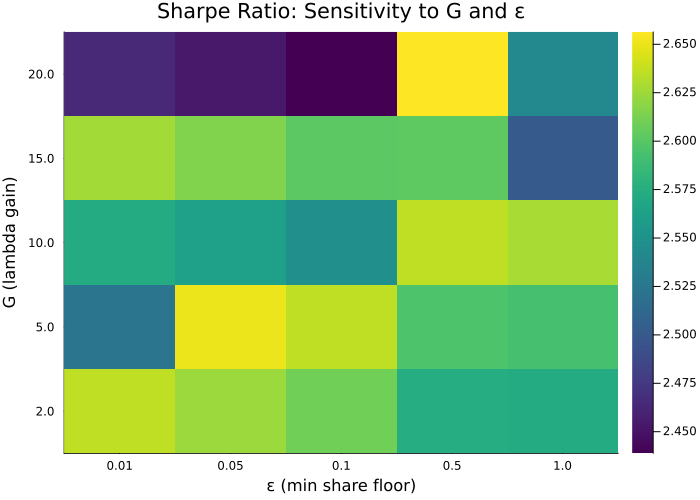

print device already activated


In [8]:
let
    # --- Step 1: Define axis tick labels matching the sweep ---
    G_values = [2.0, 5.0, 10.0, 15.0, 20.0];
    ε_values = [0.01, 0.05, 0.1, 0.5, 1.0];

    # --- Step 2: Plot the Sharpe ratio heatmap ---
    heatmap(string.(ε_values), string.(G_values), sharpe_grid,
        xlabel="ε (min share floor)", ylabel="G (lambda gain)",
        title="Sharpe Ratio: Sensitivity to G and ε",
        color=:viridis, size=(700, 500),
        clim=(minimum(sharpe_grid), maximum(sharpe_grid)))
end

The code below generates a heatmap of final wealth across the same $(G, \epsilon)$ parameter space.

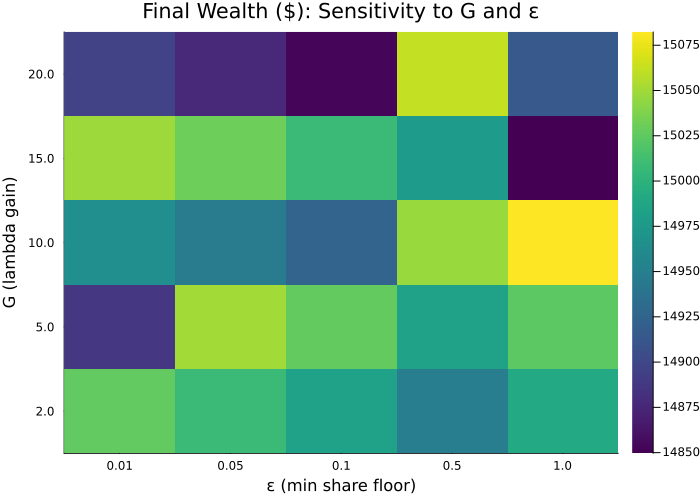

In [9]:
let
    # --- Step 1: Define axis tick labels matching the sweep ---
    G_values = [2.0, 5.0, 10.0, 15.0, 20.0];
    ε_values = [0.01, 0.05, 0.1, 0.5, 1.0];

    # --- Step 2: Plot the final wealth heatmap ---
    heatmap(string.(ε_values), string.(G_values), wealth_grid,
        xlabel="ε (min share floor)", ylabel="G (lambda gain)",
        title="Final Wealth (\$): Sensitivity to G and ε",
        color=:viridis, size=(700, 500))
end

The code below identifies the best and worst parameter combinations from the `sharpe_grid` and `wealth_grid` matrices.

In [10]:
let
    # --- Step 1: Recreate parameter grids for indexing ---
    G_values = [2.0, 5.0, 10.0, 15.0, 20.0];
    ε_values = [0.01, 0.05, 0.1, 0.5, 1.0];

    # --- Step 2: Find the (G, ε) pair with the highest and lowest Sharpe ---
    best_idx = argmax(sharpe_grid);    # CartesianIndex of best Sharpe
    worst_idx = argmin(sharpe_grid);   # CartesianIndex of worst Sharpe

    # --- Step 3: Print results ---
    println("Best Sharpe:  G=$(G_values[best_idx[1]]), ε=$(ε_values[best_idx[2]]) → Sharpe=$(round(sharpe_grid[best_idx], digits=3)), Wealth=\$$(round(wealth_grid[best_idx], digits=2))")
    println("Worst Sharpe: G=$(G_values[worst_idx[1]]), ε=$(ε_values[worst_idx[2]]) → Sharpe=$(round(sharpe_grid[worst_idx], digits=3)), Wealth=\$$(round(wealth_grid[worst_idx], digits=2))")
end

Best Sharpe:  G=20.0, ε=0.5 → Sharpe=2.656, Wealth=$15061.39
Worst Sharpe: G=20.0, ε=0.1 → Sharpe=2.439, Wealth=$14852.03


___
## Summary
This example ran the Cobb-Douglas rebalancing engine with production-style trigger rules on the single hybrid-SIM path generated in Example 1, compared it against the Session 1 min-var portfolio plus equal-weight and risk-free baselines via a four-row scorecard, and mapped the sensitivity of the engine's Sharpe ratio and final wealth across a grid of $(G, \epsilon)$ parameter values. The scorecard and engine wealth series are saved to `session2-scorecard.jld2` for downstream sessions.

### Key Takeaways
* __Drawdown limits act as circuit breakers:__ Tighter drawdown thresholds cause the engine to de-risk to cash earlier, protecting capital at the cost of missing recoveries. Looser thresholds allow more volatility but capture more upside.
* __The scorecard quantifies the adaptability trade-off:__ The Cobb-Douglas engine adapts to market conditions by adjusting allocations, but this comes at the cost of higher turnover. Comparing against the Session 1 min-var portfolio makes the adaptive-vs-static trade-off explicit.
* __Sensitivity analysis reveals a parameter sweet spot:__ The lambda gain and epsilon parameters control engine responsiveness and diversification, respectively. Sweeping these parameters exposes regions where the engine is unresponsive, over-reactive, or well-tuned.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.